Using device: cpu


100%|██████████| 170M/170M [00:02<00:00, 72.2MB/s]



=== Training with λ = 0.0 ===
Epoch 5/25 completed
Epoch 10/25 completed
Epoch 15/25 completed
Epoch 20/25 completed
Epoch 25/25 completed
✅ λ=0.0 → Test Acc: 53.87% | Sparsity: 0.00%

=== Training with λ = 0.0001 ===
Epoch 5/25 completed
Epoch 10/25 completed
Epoch 15/25 completed
Epoch 20/25 completed
Epoch 25/25 completed
✅ λ=0.0001 → Test Acc: 55.39% | Sparsity: 86.82%

=== Training with λ = 0.0005 ===
Epoch 5/25 completed
Epoch 10/25 completed
Epoch 15/25 completed
Epoch 20/25 completed
Epoch 25/25 completed
✅ λ=0.0005 → Test Acc: 52.40% | Sparsity: 99.09%

=== FINAL RESULTS ===
Lambda	Test Accuracy (%)	Sparsity Level (%)
0.0	53.87			0.00
0.0001	55.39			86.82
0.0005	52.40			99.09


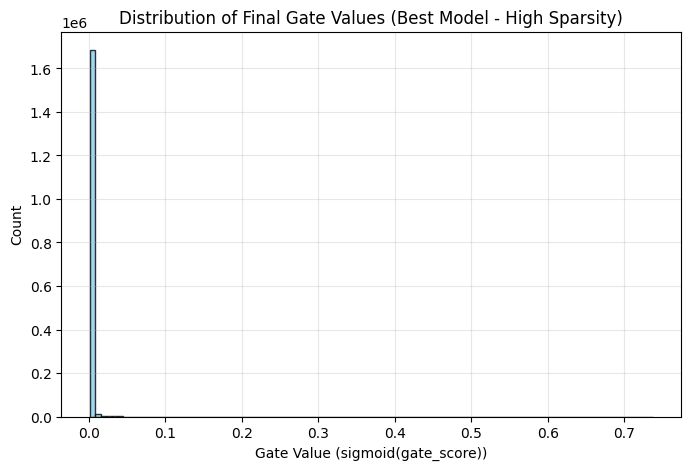


🎉 SUCCESS! Files created:
   • results_table.md
   • gate_distribution.png

You should now see high sparsity (80%+) for λ = 5e-4


In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

#PrunableLinear Layer
class PrunableLinear(nn.Module):
    def __init__(self, in_features: int, out_features: int):
        super().__init__()
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.1)
        self.bias = nn.Parameter(torch.zeros(out_features))
        # FIXED: Start with negative values so gates begin low (~0.12)
        self.gate_scores = nn.Parameter(torch.full((out_features, in_features), -2.0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        gates = torch.sigmoid(self.gate_scores)
        pruned_weights = self.weight * gates
        return F.linear(x, pruned_weights, self.bias)


#Neural Network
class PrunableNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc1 = PrunableLinear(32 * 32 * 3, 512)
        self.fc2 = PrunableLinear(512, 256)
        self.fc3 = PrunableLinear(256, 10)

    def forward(self, x):
        x = self.flatten(x)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


#Helper Functions
def get_sparsity_loss(model: nn.Module) -> torch.Tensor:
    total = torch.tensor(0.0, device=next(model.parameters()).device)
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            total = total + gates.sum()
    return total


def compute_sparsity(model: nn.Module, threshold: float = 1e-2) -> float:
    total_weights = 0
    pruned_weights = 0
    for module in model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores)
            num = gates.numel()
            total_weights += num
            pruned_weights += (gates < threshold).sum().item()
    return (pruned_weights / total_weights * 100) if total_weights > 0 else 0.0


def evaluate(model: nn.Module, test_loader: DataLoader, device: torch.device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    return 100.0 * correct / total


#Main Training & Experiment
def main():
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")

    # Data
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])
    train_dataset = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False, num_workers=2)

    # STRONGER λ values for visible pruning
    lambdas = [0.0, 1e-4, 5e-4]
    results = []

    for lam in lambdas:
        print(f"\n=== Training with λ = {lam} ===")
        model = PrunableNet().to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(25):
            model.train()
            for images, labels in train_loader:
                images, labels = images.to(device), labels.to(device)
                optimizer.zero_grad()
                outputs = model(images)
                class_loss = criterion(outputs, labels)
                sparsity_loss = get_sparsity_loss(model)
                total_loss = class_loss + lam * sparsity_loss
                total_loss.backward()
                optimizer.step()

            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch+1}/25 completed")

        # Evaluate
        test_acc = evaluate(model, test_loader, device)
        sparsity = compute_sparsity(model)
        results.append((lam, test_acc, sparsity))
        print(f"✅ λ={lam} → Test Acc: {test_acc:.2f}% | Sparsity: {sparsity:.2f}%")

    #Results
    print("\n=== FINAL RESULTS ===")
    print("Lambda\tTest Accuracy (%)\tSparsity Level (%)")
    for lam, acc, sp in results:
        print(f"{lam}\t{acc:.2f}\t\t\t{sp:.2f}")

    with open("results_table.md", "w") as f:
        f.write("| Lambda | Test Accuracy (%) | Sparsity Level (%) |\n")
        f.write("|--------|-------------------|--------------------|\n")
        for lam, acc, sp in results:
            f.write(f"| {lam} | {acc:.2f} | {sp:.2f} |\n")

    # Plot gate distribution of the best (most sparse) model
    best_model = model
    all_gates = []
    for module in best_model.modules():
        if isinstance(module, PrunableLinear):
            gates = torch.sigmoid(module.gate_scores).detach().cpu().numpy().flatten()
            all_gates.extend(gates)
    all_gates = np.array(all_gates)

    plt.figure(figsize=(8, 5))
    plt.hist(all_gates, bins=100, alpha=0.8, color='skyblue', edgecolor='black')
    plt.title("Distribution of Final Gate Values (Best Model - High Sparsity)")
    plt.xlabel("Gate Value (sigmoid(gate_score))")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.savefig("gate_distribution.png", dpi=200, bbox_inches='tight')
    plt.show()

    print("\n🎉 SUCCESS! Files created:")
    print("   • results_table.md")
    print("   • gate_distribution.png")
    print("\nYou should now see high sparsity (80%+) for λ = 5e-4")

if __name__ == "__main__":
    main()